# AstroLogics Tutorial: Boolean Network Analysis and Clustering (Herault Hematopoiesis)

This tutorial demonstrates the AstroLogics framework for analyzing and comparing Boolean network model ensembles. AstroLogics is designed for benchmarking Boolean models through three major evaluation criteria: network evaluation, logical function evaluation, and dynamic evaluation.

## Overview of AstroLogics Framework

AstroLogics addresses a critical gap in Boolean network modeling: while multiple methods exist for Boolean model synthesis (like Bonesis, BN-sketch), there hasn't been a standardized way to evaluate and compare generated model ensembles. The framework focuses on:

- **Dynamic properties**: Examining state transition graphs and model behaviors through simulation
- **Logical function evaluation**: Analyzing and comparing logical rules that govern node behaviors
- **Model clustering**: Identifying groups of models with similar dynamics and logical features

## Required Libraries

In [ ]:
import pandas as pd 
import sys
sys.path.append("../../src")
import astrologics as ast
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import os
os.chdir('../../')

### Dataset: Herault hematopoiesis model

We'll use the Herault Hematopoiesis model from Herault et al., 2018, which provides an excellent framework for studying blood cell differentiation. This model contains 33 nodes representing key transcription factors and signaling molecules involved in hematopoietic lineage specification. The model demonstrates hierarchical decision-making processes during blood cell development from hematopoietic stem cells to differentiated blood cell types.

## Step 1: Load Model Ensemble

In [6]:
model_path = './models/herault_hematopoiesis/'
model = ast.ensemble(model_path, project_name = 'herault_hematopoiesis')
model.create_simulation()

Simulation object created


The `ensemble` object is the core component of AstroLogics that handles:

- Loading multiple Boolean network models from a directory
- Managing simulation parameters and configurations
- Coordinating analysis across the model ensemble

## Step 2: Simulate the model ensemble

In this part of the script, we first simulate all BNs within the model ensemble. We use the MaBoSS engine as the main simulator.

This creates an initial state where all nodes have equal probability (0.5) of being active. This represents a neutral starting condition that allows the system to evolve according to its inherent dynamics.

We then start the simulation using MaBoSS.

**MaBoSS** (Markovian Boolean Stochastic Simulator) is crucial for the AstroLogics approach because:

- It converts Boolean network dynamics into continuous-time Markov processes
- Provides probabilistic approximation of complex state transition graphs
- Enables analysis of both transient and steady-state behaviors
- Scales computationally better than exhaustive state space exploration

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


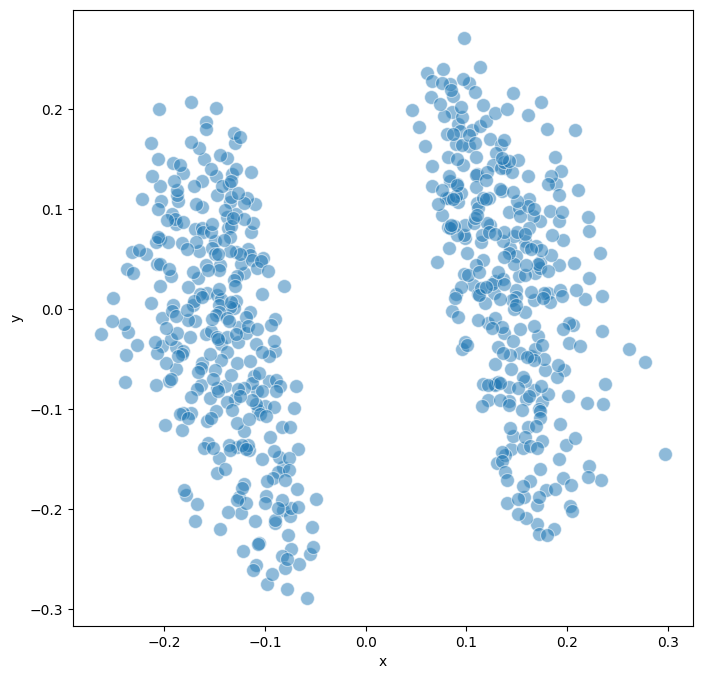

In [7]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 5,thread_count = 15, sample_count = 2000)
model.simulation.run_simulation()
model.create_trajectory()
# Calculate the distance matrix
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


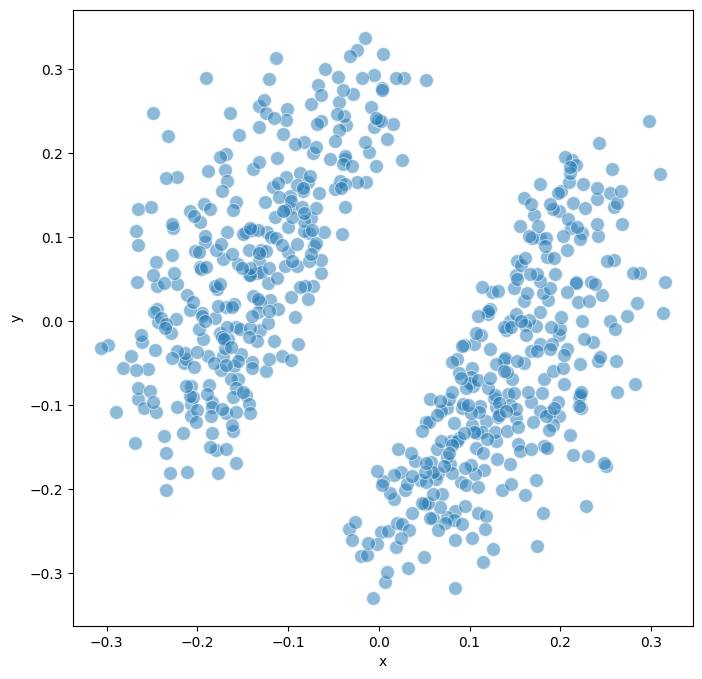

In [8]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 10,thread_count = 15, sample_count = 2000)
model.simulation.run_simulation()
model.create_trajectory()
# Calculate the distance matrix
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


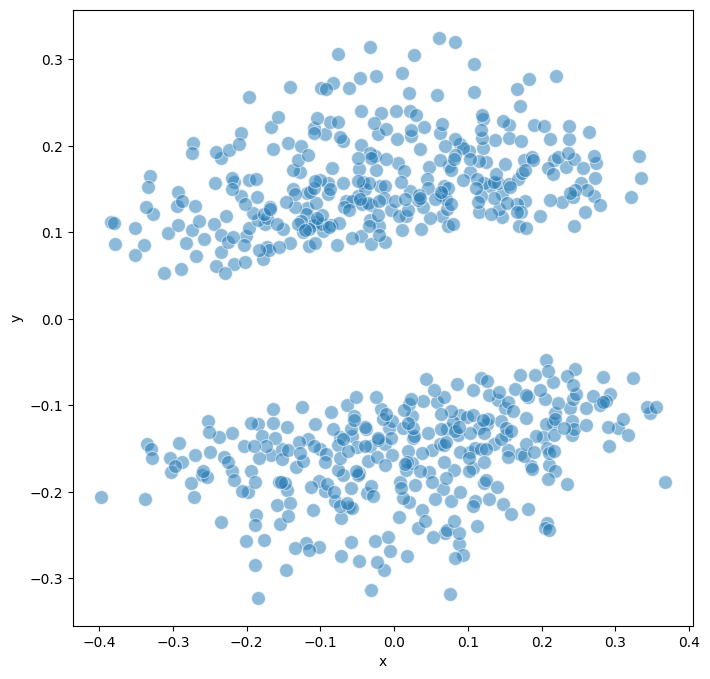

In [9]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 20,thread_count = 15, sample_count = 2000)
model.simulation.run_simulation()
model.create_trajectory()
# Calculate the distance matrix
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


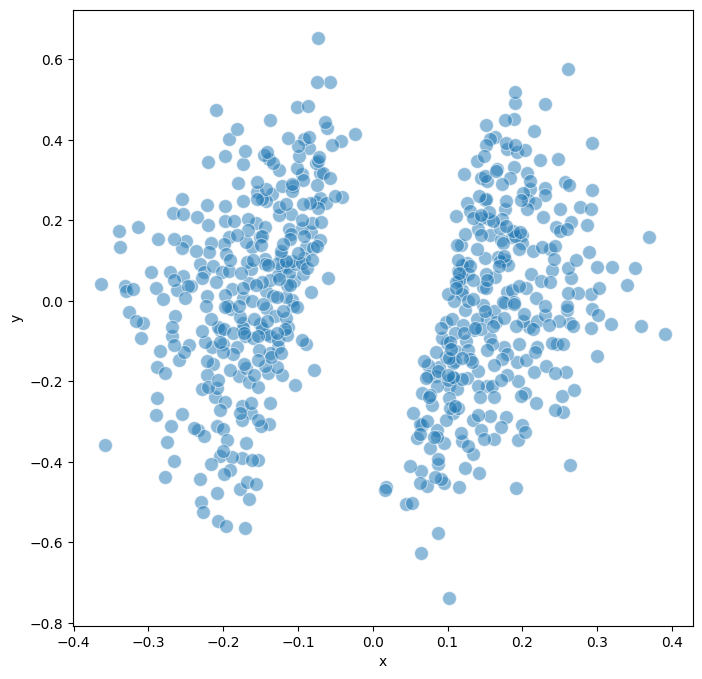

In [10]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 50,thread_count = 15, sample_count = 2000)
model.simulation.run_simulation()
model.create_trajectory()
# Calculate the distance matrix
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


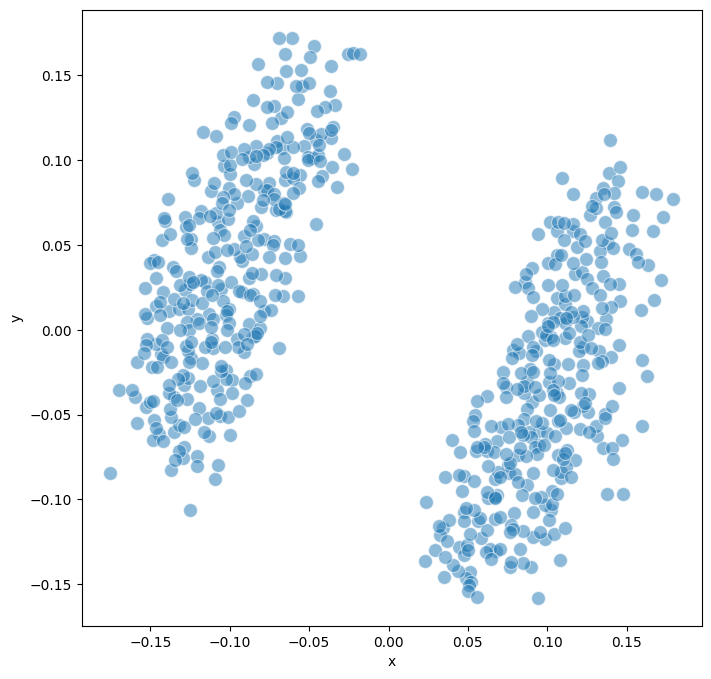

In [11]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 2,thread_count = 15, sample_count = 2000)
model.simulation.run_simulation()
model.create_trajectory()
# Calculate the distance matrix
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.
Start simulation


...

Distance matrix calculated successfully.
Start simulation


  0%|          | 0/616 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/616 [00:00<?, ?it/s]

Distance matrix calculated successfully.


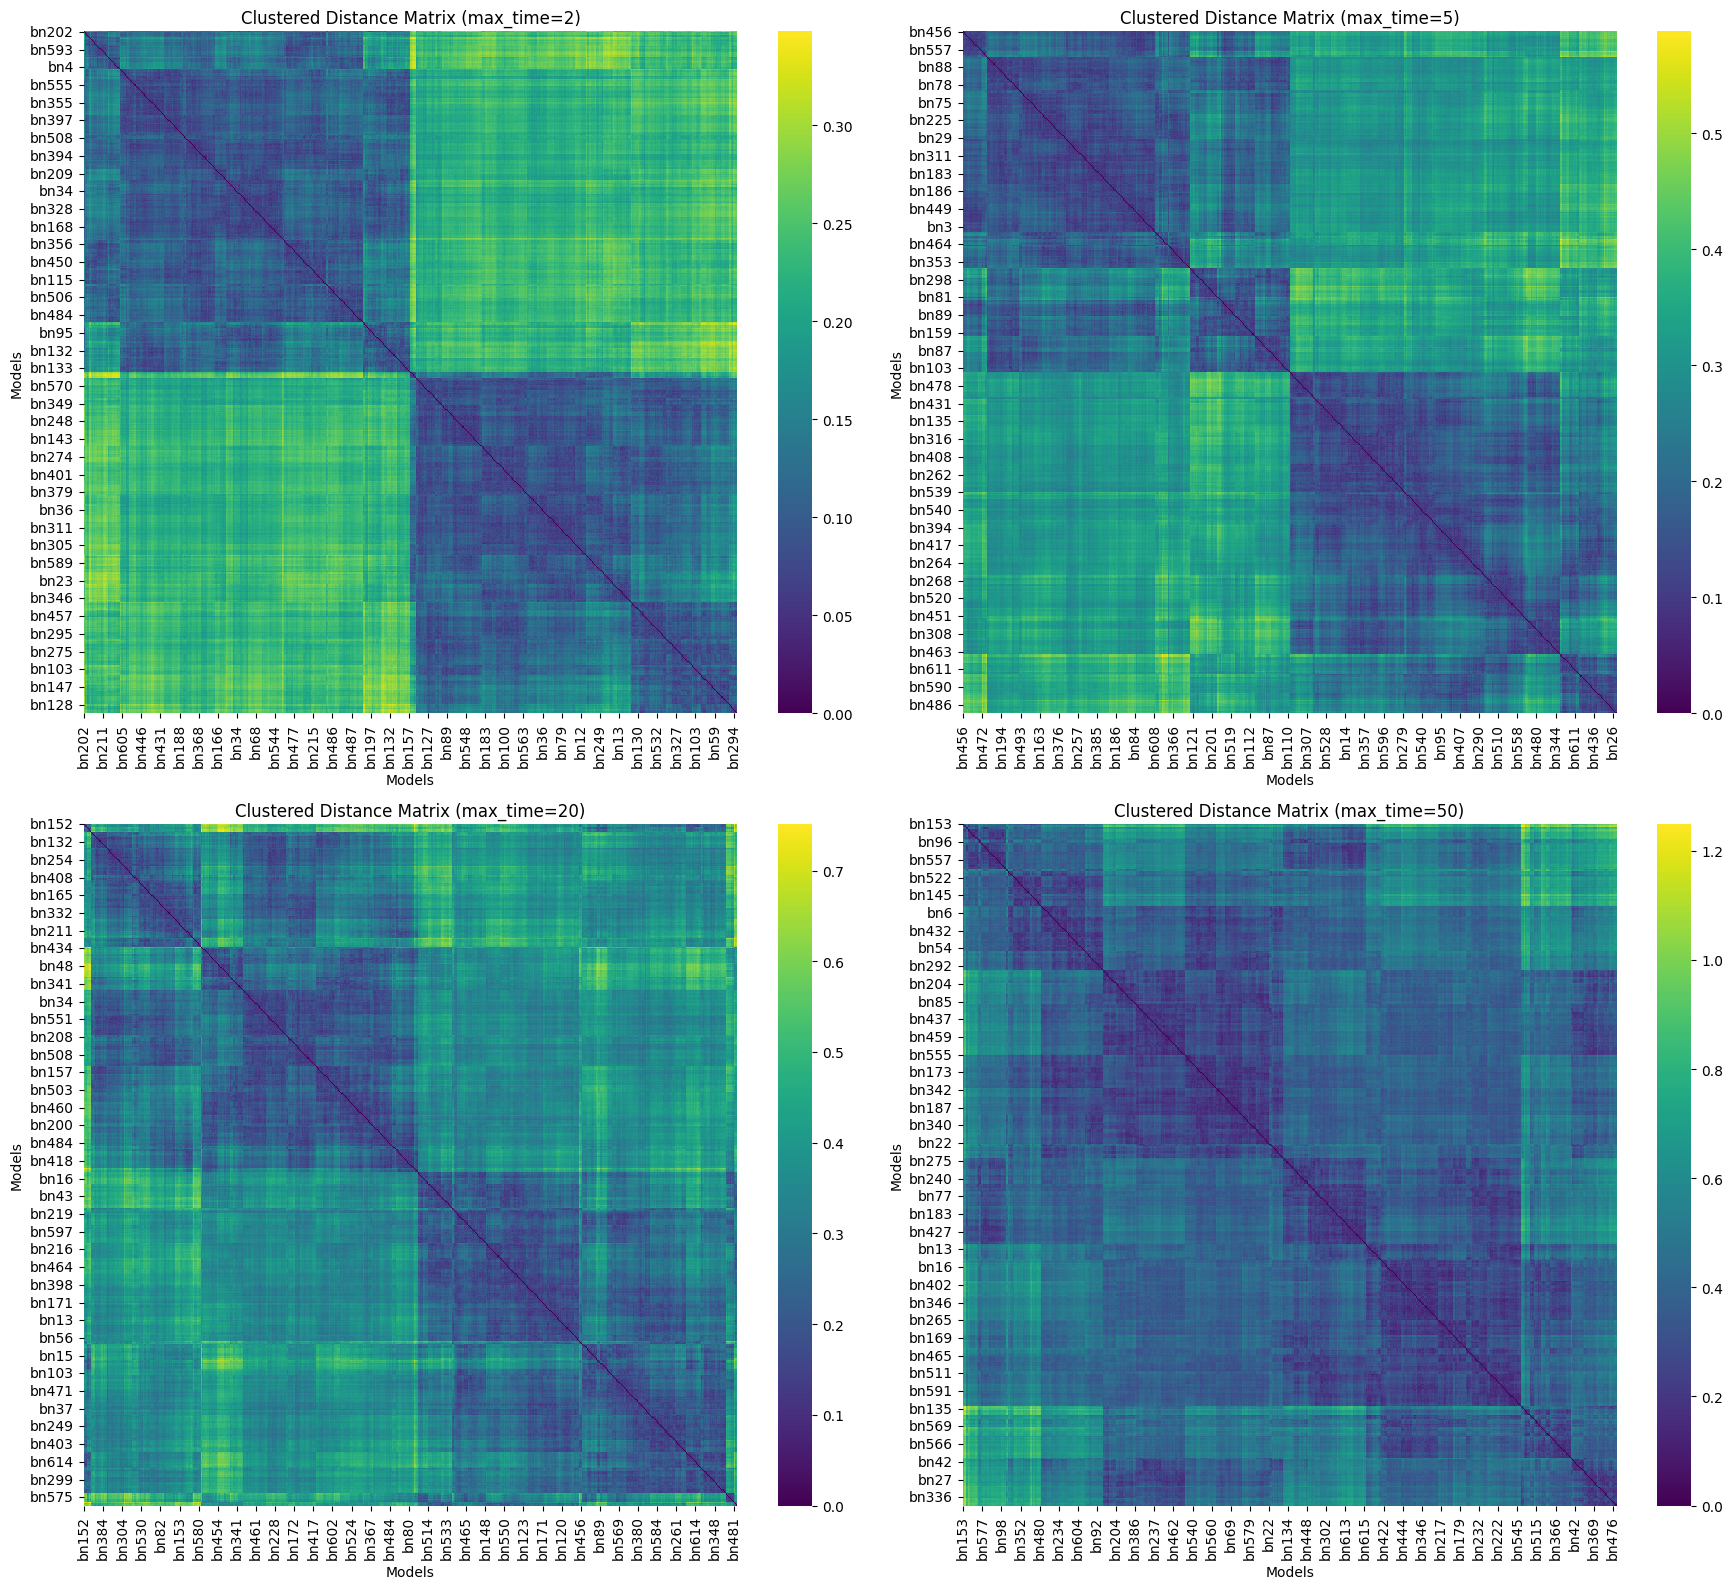

In [12]:
# Simulate for multiple max_time values and collect distance matrices
max_times = [2, 5, 20, 50]
distance_matrices = {}

for t in max_times:
    model.simulation.update_parameters(max_time=t, thread_count=15, sample_count=2000)
    model.simulation.run_simulation()
    model.create_trajectory()
    model.trajectory.calculate_distancematrix(mode='trajectory')
    distance_matrices[t] = model.trajectory.distance_matrix.copy()

NameError: name 'np' is not defined

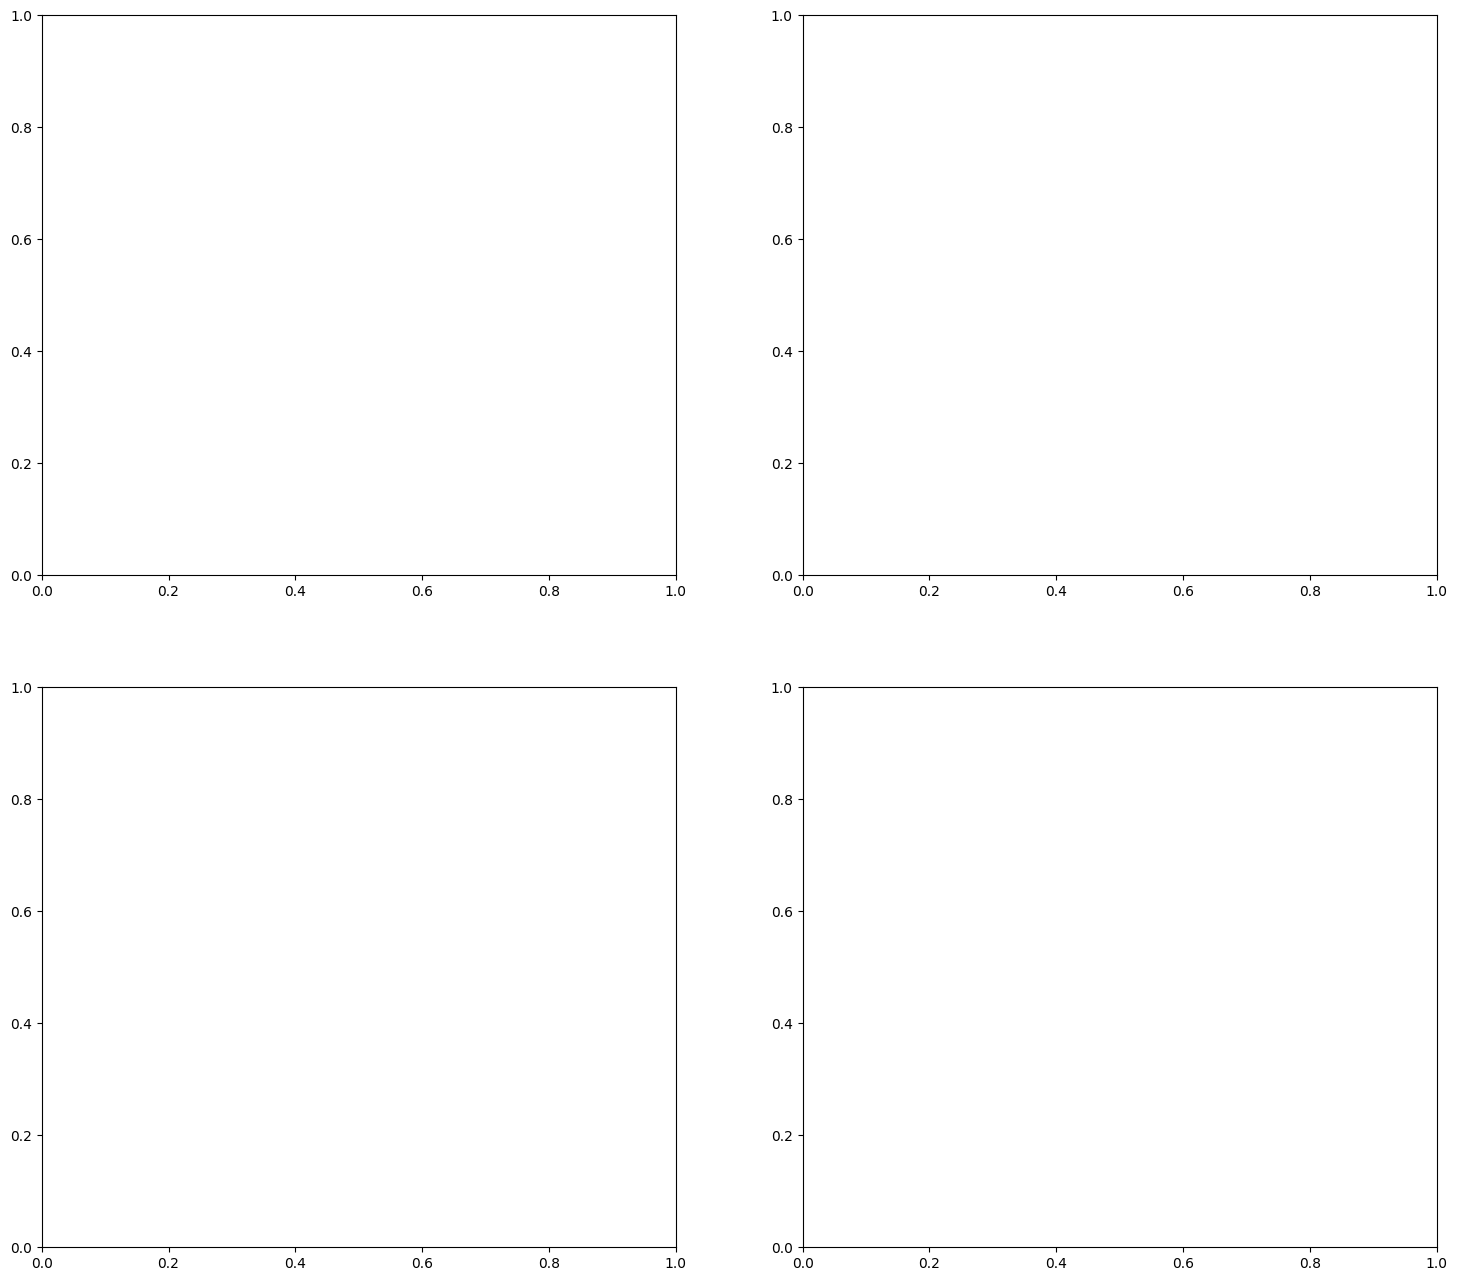

In [13]:
# Plot clustered distance matrices in 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

# Use a shared color scale across all plots
all_arrays = [dm.values if hasattr(dm, 'values') else np.asarray(dm) for dm in distance_matrices.values()]
global_vmin = min(np.nanmin(arr) for arr in all_arrays)
global_vmax = max(np.nanmax(arr) for arr in all_arrays)

for ax, t in zip(axes, max_times):
    dm = distance_matrices[t]

    # Use clustermap to get clustered ordering
    cg = sns.clustermap(dm, cmap='viridis')
    row_order = cg.dendrogram_row.reordered_ind
    col_order = cg.dendrogram_col.reordered_ind
    plt.close(cg.figure)

    # Reorder matrix and plot in subplot
    if hasattr(dm, 'iloc'):
        dm_clustered = dm.iloc[row_order, col_order]
    else:
        dm_clustered = dm[np.ix_(row_order, col_order)]

    sns.heatmap(
        dm_clustered,
        ax=ax,
        cmap='viridis',
        vmin=global_vmin,
        vmax=global_vmax,
        cbar=True,
        cbar_kws={'label': 'Distance'}
    )
    ax.set_title(f'Clustered Distance Matrix (max_time={t})')
    ax.set_xlabel('Models')
    ax.set_ylabel('Models')

plt.tight_layout()

## Step 4: Model Clustering

Clustering reveals distinct groups within the model ensemble. In this example, we found 2 major clusters corresponding to different attractor groups, representing distinct cellular fate decisions.

In [8]:
model.trajectory.calculate_kmean_cluster(n_cluster = 2,
                              random_state = 0)

Calculated k-means clustering with 2 clusters.


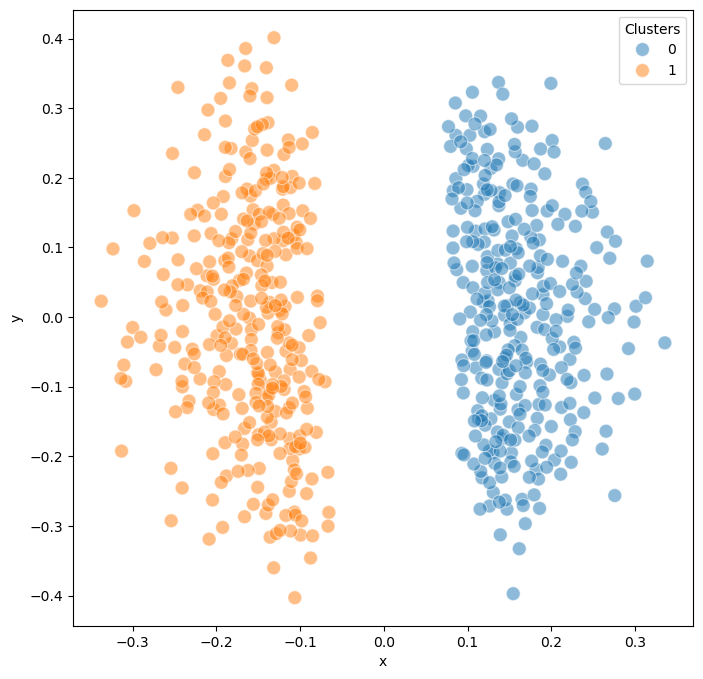

In [9]:
model.trajectory.plot_MDS(s = 100, fig_size = (8,8),plot_cluster = True)

## Step 5: Logic Function Analysis

This step implements the **logical function evaluation** component of AstroLogics:

- Converts Boolean equations to Disjunctive Normal Form (DNF)
- Creates feature matrices comparing logical rules across models
- Identifies **constant**, **varied**, and **marker** clauses

In [10]:
model.create_logic()
model.logic.model_logic
model.logic.create_flattend_logic_clause()

Loading models logics


  0%|          | 0/616 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/616 [00:00<?, ?it/s]

Logic object created
Flatten models logic clauses


  0%|          | 0/616 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/616 [00:00<?, ?it/s]

Flattend logic clause created


## Step 6: Calculate statistics of logic features (clauses)

In this step, we have already featurized the logical equations into model logic features (clauses).

We can then integrate the clusters obtained from trajectory analysis into `.logic` and perform a chi-square statistical test to categorize logic features (clauses) into three major groups:

- Constant: Core regulatory features that appear across BNs in the model ensemble
- Varied: Features that may differ between individual BNs but show no statistical significance
- Marker: Key discriminatory features that statistically distinguish between different model clusters

We can define the p-value threshold for the chi-square test using the `pval_threshold` parameter.


In [11]:
model.logic.map_model_clusters(model.trajectory.cluster_dict)
model.logic.calculate_logic_statistic(pval_threshold = 0.0001)

Model clusters mapped to logic clauses


The results of the analysis can be visualized in the form of Manhattan Plot shown below.

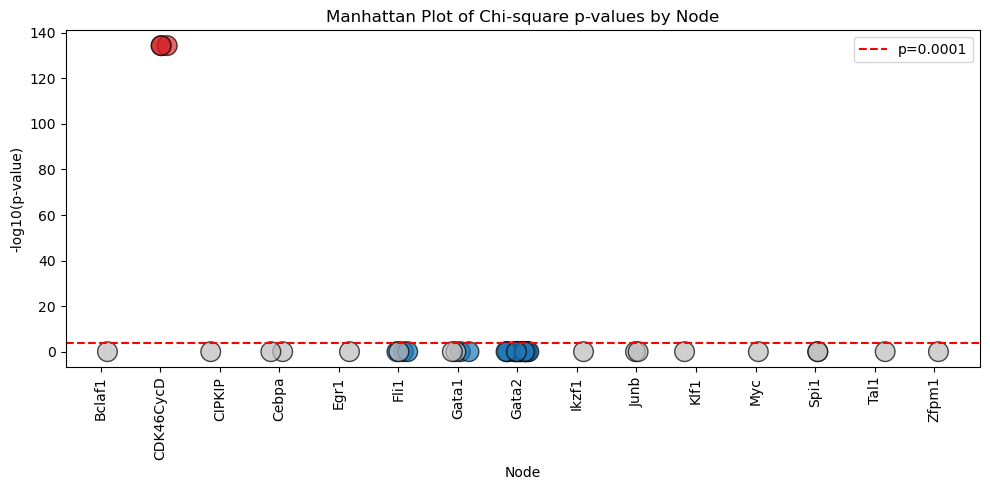

In [12]:

model.logic.plot_manhattan()

Or the results can be summarized in the bar plot shown here.

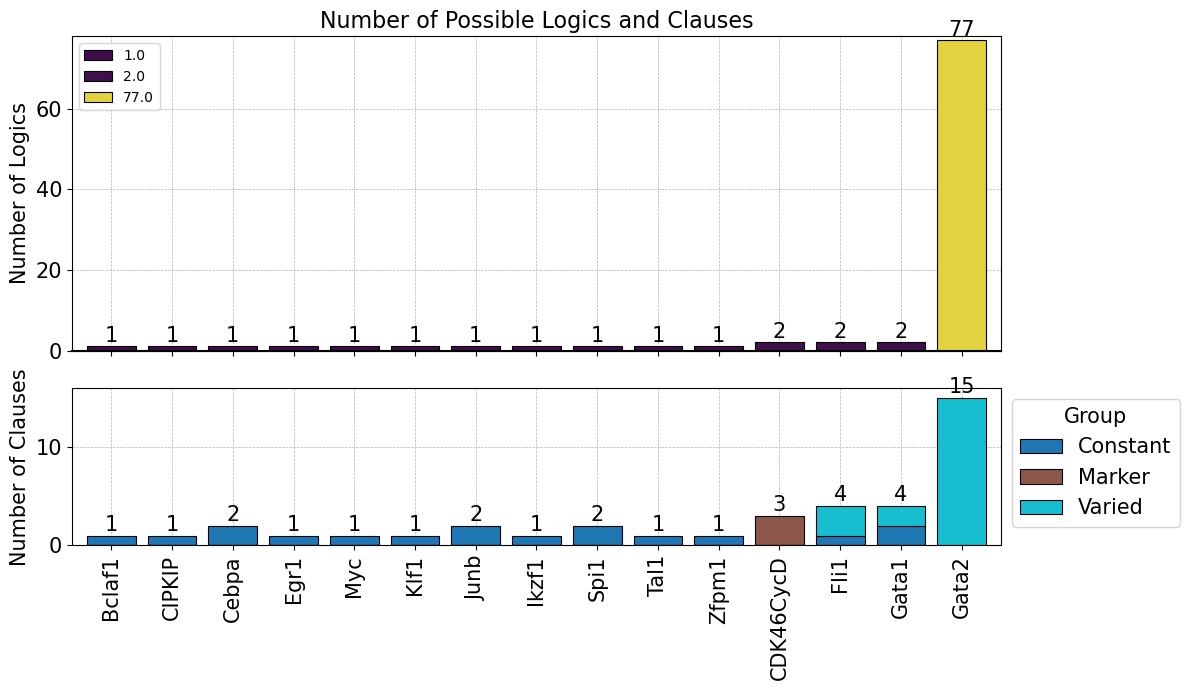

In [13]:
model.logic.plot_logicstat_summary()

## Step 7: Advanced Trajectory Analysis

These visualizations help identify:

- **Most variable nodes**: Components showing the greatest differences between models
- **Critical regulators**: Nodes whose activity patterns distinguish model clusters
- **Temporal patterns**: How specific nodes behave over simulation time

In this first plot, we check which features show the highest variance in their dynamics across the simulation. We calculate the variance of node activation probabilities for all BNs in the model ensemble across all timepoints and plot the results as a heatmap.

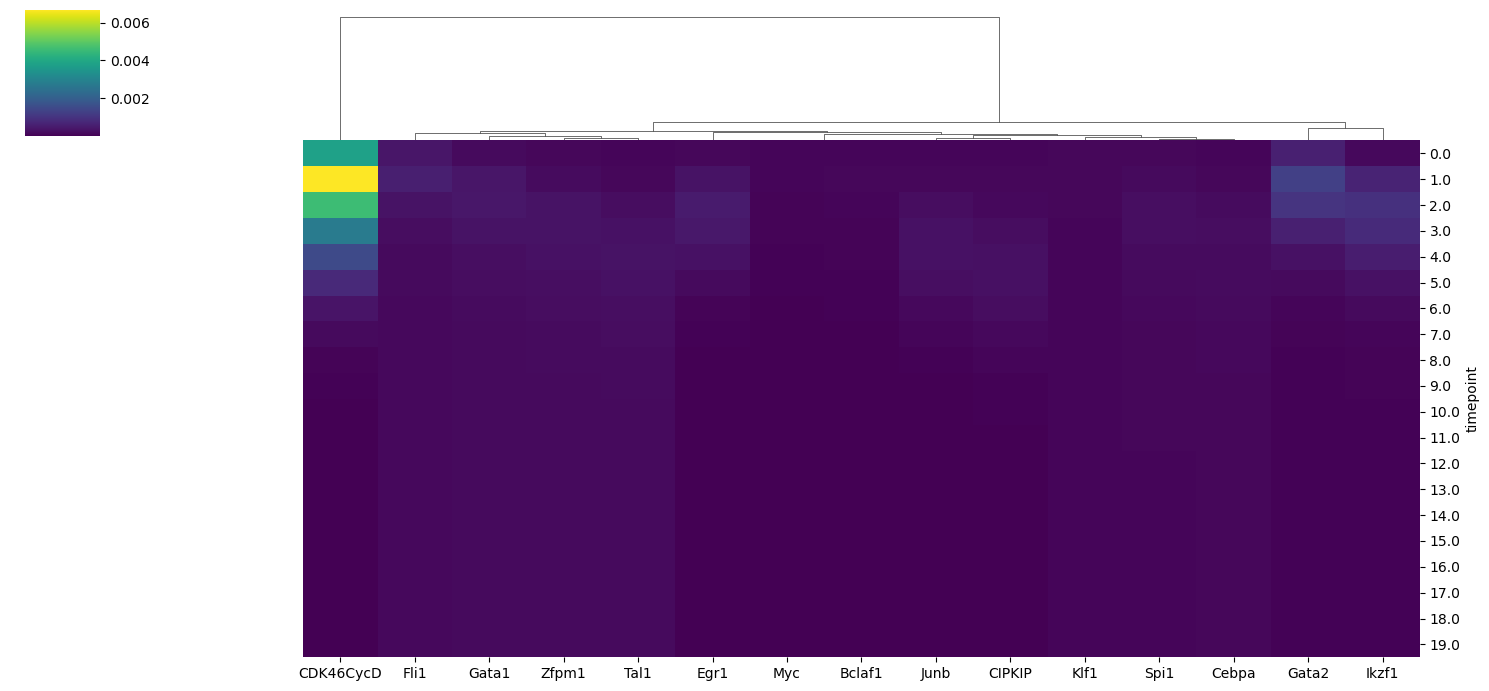

In [14]:
model.trajectory.plot_trajectory_variance()

We identify the key node of interest (CDK46CycD), which shows the highest variance across timepoints.
Finally, we can visualize the dynamics of this node between the two identified clusters using a line plot.

From this, we found that the dynamics of this node differ during the early simulation timepoints, and then finally converge to 0 at later timepoints.

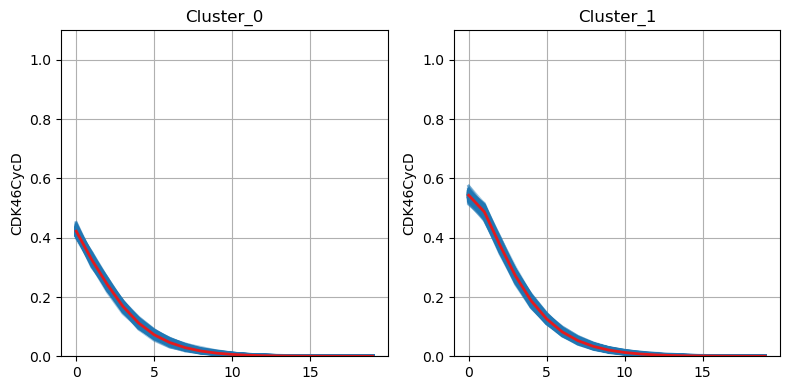

In [15]:
model.trajectory.plot_node_trajectory(node = ['CDK46CycD'])

## Step 8: Logic Feature Heatmap

This analysis typically reveals that **CDK46CycD** is the key distinguishing node between clusters:

- **Cluster 0**: CDK46CycD is regulated by Bclaf1 & Myc
- **Cluster 1**: CDK46CycD is regulated by Bclaf1 | Myc

<Figure size 800x800 with 0 Axes>

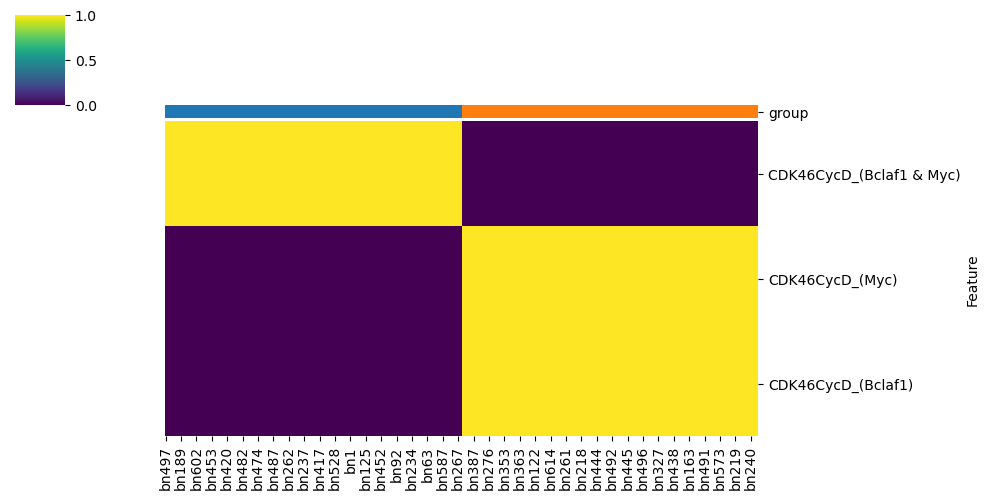

In [16]:
model.logic.plot_node_logic_heatmap(node = ['CDK46CycD'],
                                     fig_size = (8, 8))